# Error Analysis of Euler's Method 

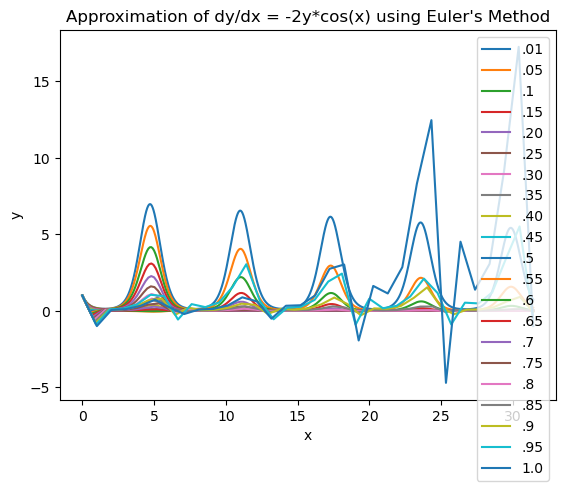

In [53]:
import numpy as np
import matplotlib.pyplot as plt
#Array of Step Sizes
h = np.array([.01,.05,.1,.15,.20,.25,.30,.35,.40,.45,.5,.55,.6,.65,.7,.75,.8,.85,.9,.95,1.0]) # step size
#String for plot labels
string=np.array([".01",".05",".1",".15",".20",".25",".30",".35",".40",".45",".5",".55",".6",".65",".7",".75",".8",".85",".9",".95","1.0"])
#Initialize Error Arrays
avg_error=np.zeros(h.size)
local_error=np.zeros(h.size)
#Loop through step sizes
for i in range (0,h.size):
    x_start, x_end = 0, 10*np.pi
    num_steps = int((x_end - x_start) / h[i])
    x_values = np.linspace(x_start, x_end, num_steps + 1) #Create x values
    y_values = np.zeros(num_steps + 1) #Initialize y-values
    # Initial condition
    y_values[0] = 1 # y(0) = 1
    # Function representing dy/dx = -2y
    def f(x, y):
        return -2 * y*np.cos(x)
    # Implement Euler's method
    for j in range(num_steps):
        y_values[j + 1] = y_values[j] + h[i] *f(x_values[j], y_values[j])
    if i==0:
        y_base=np.mean(y_values)
        y_15=np.mean(y_values[(x_values<=15+.5) & (x_values>=15-.5)])
    avg_error[i]=np.abs(y_base-np.mean(y_values)) #Caclulate average error
    local_error[i]=np.abs(y_15-np.mean(y_values[(x_values<=15+.5) & (x_values>=15-.45)])) #Calculate local error
    plt.plot(x_values,y_values, label=string[i]) #Plot each Euler's approximation
plt.xlabel('x')
plt.ylabel('y')
plt.title("Approximation of dy/dx = -2y*cos(x) using Euler's Method")
plt.legend()
plt.show()

Text(0.5, 0, 'Step Size')

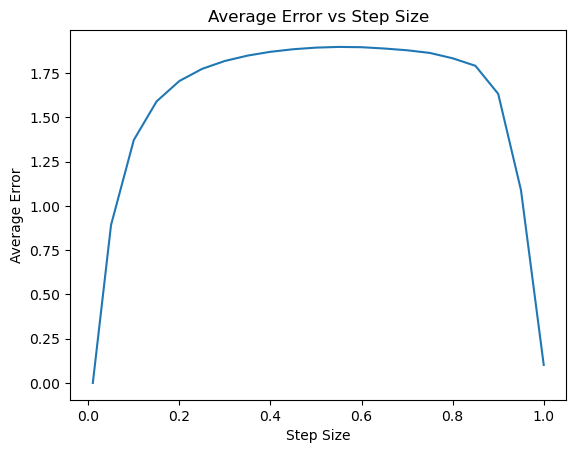

In [54]:
plt.plot(h,avg_error)
plt.title("Average Error vs Step Size")
plt.ylabel("Average Error")
plt.xlabel("Step Size")

Text(0.5, 0, 'Step Size')

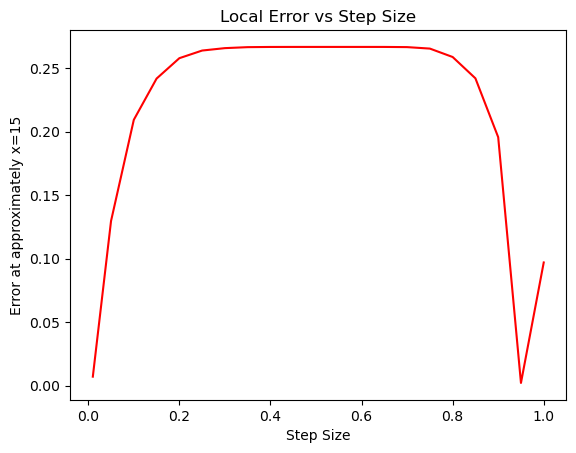

In [55]:
plt.plot(h,local_error,'r')
plt.title("Local Error vs Step Size")
plt.ylabel("Error at approximately x=15")
plt.xlabel("Step Size")

## Analysis

On plot number one you can see that towards the larger end of the step sizes the approximation becomes wildly inaccurate. This general trend is reflected in the average and local error plots, but oddly towards the end the error drops towards zero. This is not reflective of the performance of the higher step sizes compared to the middle sizes, but instead reflects the drawback of using average error or the local error at just one point because wildly inaccurate approximations can intersect at one point and show zero error and can have a similar mean while being wildly off at most points.

### Extra graph to more clearly see Euler's approximations

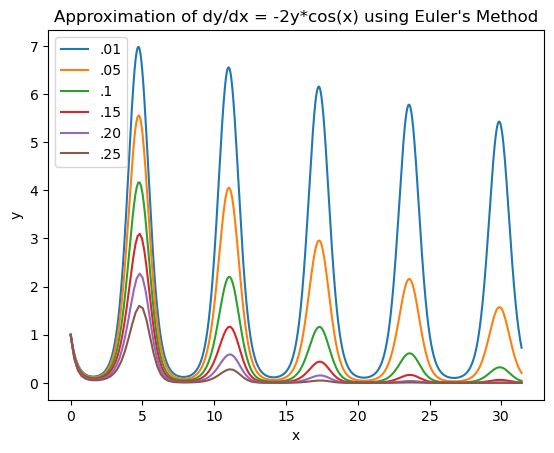

In [56]:
import numpy as np
import matplotlib.pyplot as plt
h = np.array([.01,.05,.1,.15,.20,.25])
string=np.array([".01",".05",".1",".15",".20",".25"])
for i in range (0,h.size):
    x_start, x_end = 0, 10*np.pi
    num_steps = int((x_end - x_start) / h[i])
    x_values = np.linspace(x_start, x_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)
    # Initial condition
    y_values[0] = 1 # y(0) = 1
    # Function representing dy/dx = -2y
    def f(x, y):
        return -2 * y*np.cos(x)
    # Implement Euler's method
    for j in range(num_steps):
        y_values[j + 1] = y_values[j] + h[i] *f(x_values[j], y_values[j])
    plt.plot(x_values,y_values, label=string[i])
plt.xlabel('x')
plt.ylabel('y')
plt.title("Approximation of dy/dx = -2y*cos(x) using Euler's Method")
plt.legend()
plt.show()